# Distribuce počtu lezi na obratel

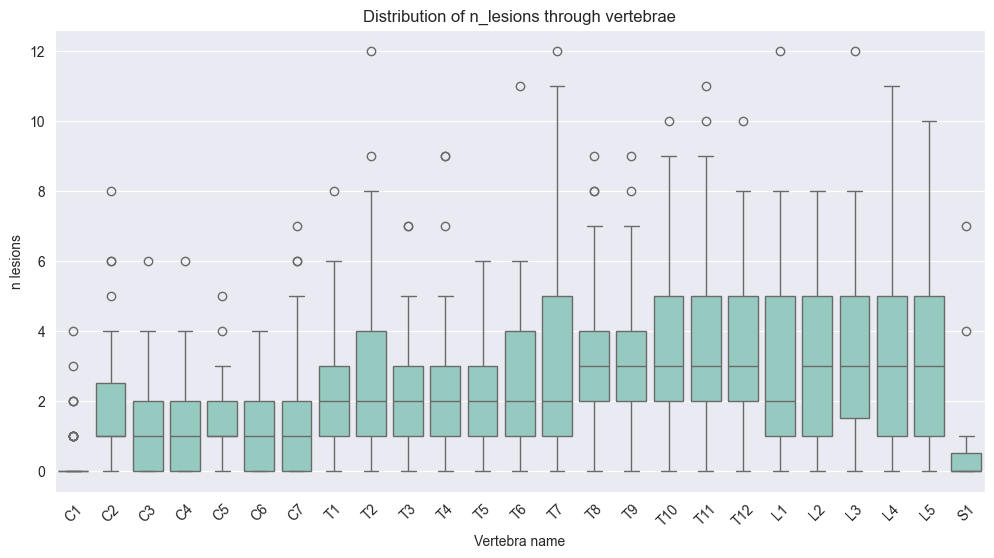

In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"
all_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    csv_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[['vertebra_name', 'n_lesions']]
        all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='n_lesions', data=full_df)
plt.title('Distribution of n_lesions through vertebrae')
plt.xlabel('Vertebra name')
plt.ylabel('n lesions')
plt.xticks(rotation=45)
plt.show()

# Relativní % obejmu lezi na obratel

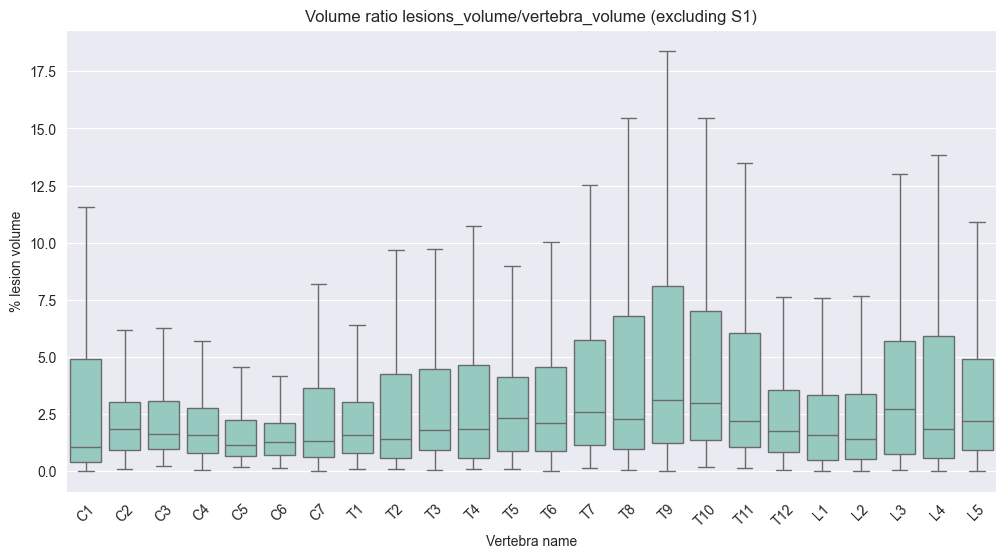

In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

main_folder = r"E:\DATA_Myelomy"

vertebra_data = []
lesion_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    vertebra_csv = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")
    lesion_csv = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")

    if os.path.isfile(vertebra_csv):
        df_v = pd.read_csv(vertebra_csv)
        df_v = df_v[['vertebra_name', 'original_shape_VoxelVolume']]
        vertebra_data.append(df_v)

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        df_l = df_l[['vertebra_name', 'original_shape_VoxelVolume']]
        lesion_data.append(df_l)

# combine all vertebra and lesion data
df_vertebra = pd.concat(vertebra_data, ignore_index=True)
df_lesion = pd.concat(lesion_data, ignore_index=True)

df_lesion["lesions_volume"] = df_lesion["original_shape_VoxelVolume"]
df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

# merge with vertebra volume, fill missing lesion sums with 0
df = pd.merge(df_vertebra, df_lesion, on='vertebra_name', how='left')

# calculate lesion percentage
df['lesion_percent'] = df['lesions_volume'] / df['vertebra_volume'] * 100

# remove S1 vertebra
df = df[df['vertebra_name'] != 'S1']

# visualization
plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.boxplot(x='vertebra_name', y='lesion_percent', data=df, showfliers=False)
plt.title('Volume ratio lesions_volume/vertebra_volume (excluding S1)')
plt.xlabel('Vertebra name')
plt.ylabel('% lesion volume')
plt.xticks(rotation=45)
plt.show()

# % podiel objemu lezi -> štádium

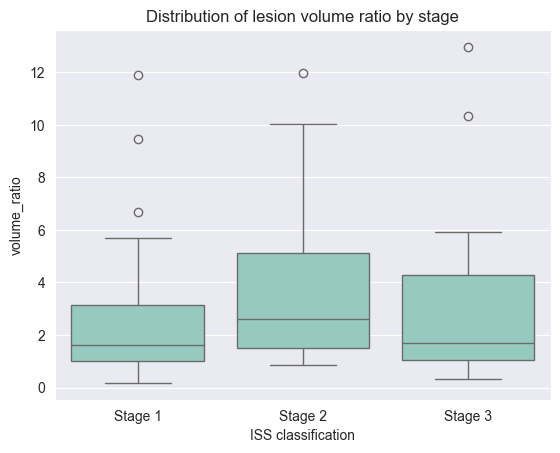

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by stage')
plt.show()

# % podiel objemu lezi -> štádium (C/T/L)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'ISS classification']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.boxplot(data=df_final, x="ISS classification", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by stage')
plt.show()

# % podiel objemu lezi -> b2 microglobulin

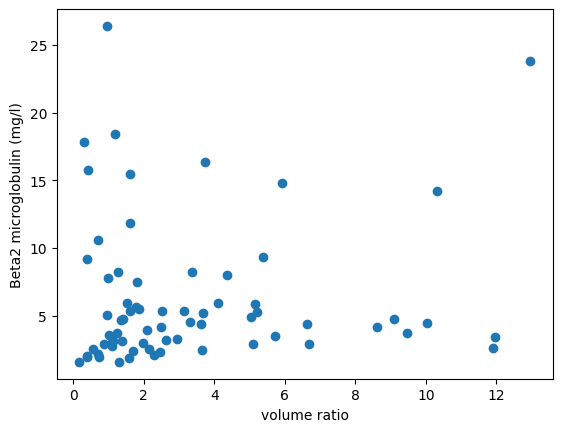

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
plt.scatter(df_final['volume_ratio'], df_final['Beta2 microglobulin (mg/l)'])
plt.xlabel('volume ratio')
plt.ylabel('Beta2 microglobulin (mg/l)')
plt.show()

3sqrt -> nelinearita

# Difference in features between vertebra -> VMI40

In [16]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

main_folder = r"E:\DATA_Myelomy"

vertebra_rows = []
lesion_rows = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        lesion_rows.append(df_l)

# combine all lesion data (this is where the radiomics live)
df = pd.concat(lesion_rows, ignore_index=True)

# keep only rows with vertebra info
df = df[df['vertebra_name'] != 'S1']

# identify feature columns automatically
non_feature_cols = ['vertebra_name', 'patient']

feature_cols = [
    c for c in df.columns if c not in non_feature_cols and pd.api.types.is_numeric_dtype(df[c])
]

results = []

for feature in feature_cols:
    groups = [
        df.loc[df['vertebra_name'] == v, feature].dropna().values
        for v in df['vertebra_name'].unique()
    ]

    try:
        H, p = kruskal(*groups)
        k = df['vertebra_name'].nunique()
        n = df[feature].notna().sum()

        results.append({
            'feature': feature,
            'H_stat': H,
            'p_value': p,
        })

    except ValueError:
        continue

results_df = pd.DataFrame(results).sort_values('H_stat', ascending=False)
results_df.head()

,feature,H_stat,p_value
199,gradient_ngtdm_Contrast,594.408267,6.807702e-111
141,gradient_glcm_InverseVariance,579.727457,8.077145e-108
140,gradient_glcm_Imc2,561.742103,4.672340e-104
180,gradient_glszm_ZonePercentage,546.185127,8.319483e-101
193,gradient_gldm_SmallDependenceEmphasis,544.247720,2.111816e-100


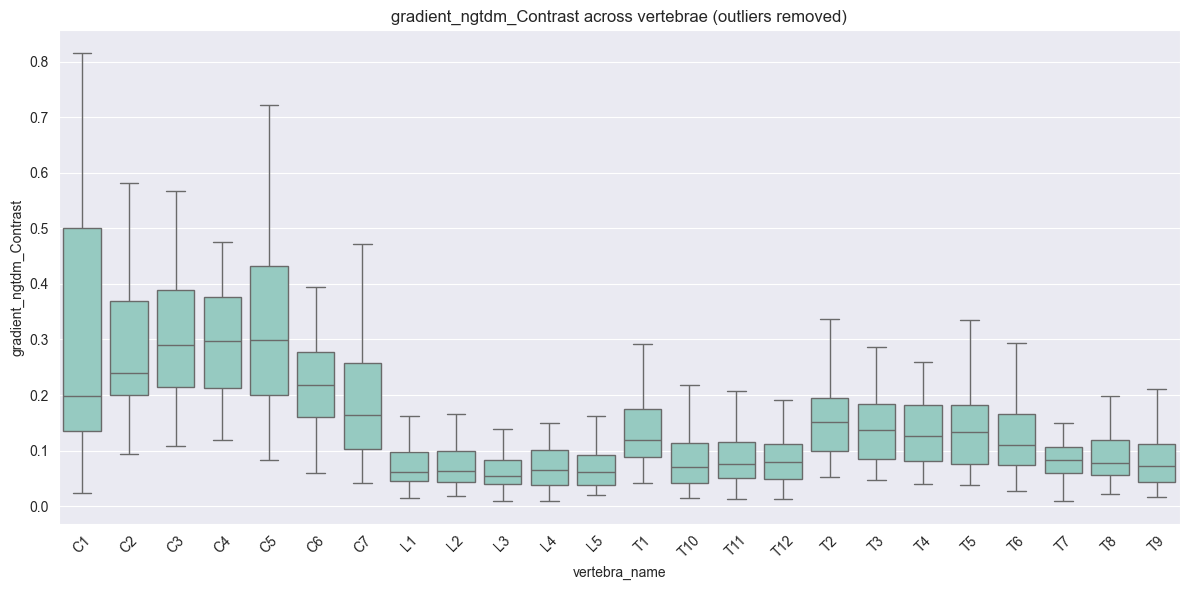

In [18]:
feature_name = 'gradient_ngtdm_Contrast'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

realtivne k zdravej tkani

# Difference in features between vertebra -> CaSupp25

In [19]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

main_folder = r"E:\DATA_Myelomy"

vertebra_rows = []
lesion_rows = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesion_csv = os.path.join(folder_path, "CaSupp_25_radiomics_lesions_features.csv")

    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        lesion_rows.append(df_l)

# combine all lesion data (this is where the radiomics live)
df = pd.concat(lesion_rows, ignore_index=True)

# keep only rows with vertebra info
df = df[df['vertebra_name'] != 'S1']

# identify feature columns automatically
non_feature_cols = ['vertebra_name', 'patient']

feature_cols = [
    c for c in df.columns
    if c not in non_feature_cols and pd.api.types.is_numeric_dtype(df[c])
]

results = []

for feature in feature_cols:
    groups = [
        df.loc[df['vertebra_name'] == v, feature].dropna().values
        for v in df['vertebra_name'].unique()
    ]

    try:
        H, p = kruskal(*groups)
        k = df['vertebra_name'].nunique()
        n = df[feature].notna().sum()

        results.append({
            'feature': feature,
            'H_stat': H,
            'p_value': p,
        })

    except ValueError:
        continue

results_df = pd.DataFrame(results)

# sort by effect size
results_df = results_df.sort_values('H_stat', ascending=False)

print(results_df.head())

                                   feature      H_stat        p_value
199                gradient_ngtdm_Contrast  551.655734  5.990251e-102
141          gradient_glcm_InverseVariance  543.029591  3.793065e-100
180          gradient_glszm_ZonePercentage  498.439279   7.455699e-91
140                     gradient_glcm_Imc2  494.021371   6.185798e-90
193  gradient_gldm_SmallDependenceEmphasis  483.176891   1.110346e-87


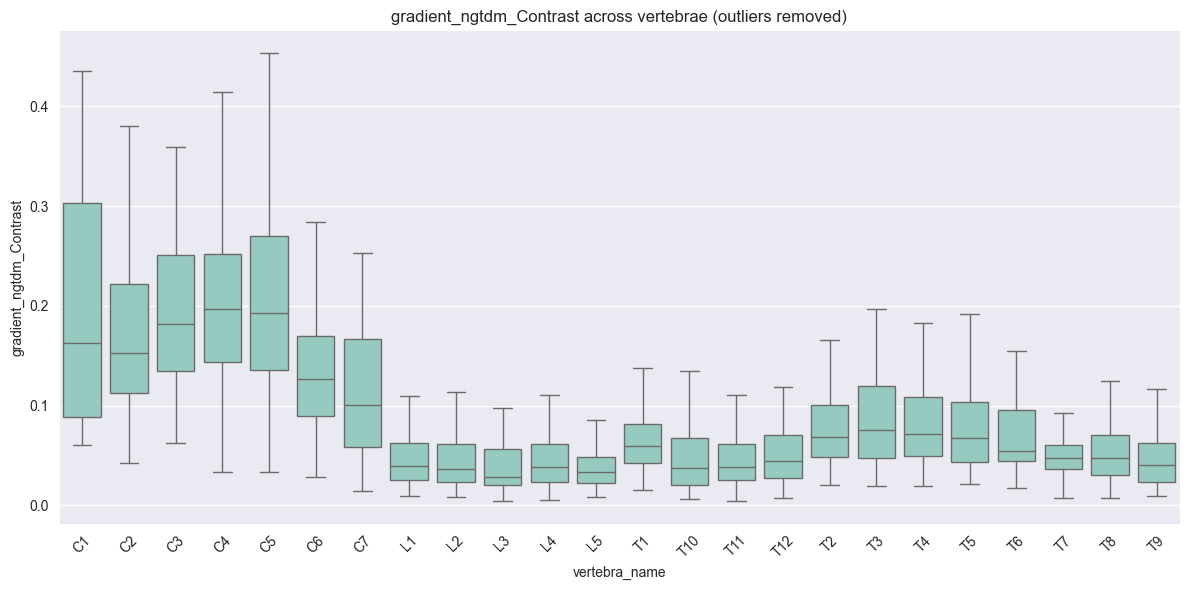

In [20]:
feature_name = 'gradient_ngtdm_Contrast'

plt.figure(figsize=(12,6))
sns.boxplot(x='vertebra_name', y=feature_name, data=df, showfliers=False, order=sorted(df['vertebra_name'].unique()))
plt.title(f'{feature_name} across vertebrae (outliers removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# C/T/L analýza

                                   feature      H_stat        p_value
141          gradient_glcm_InverseVariance  485.111835  4.563556e-106
199                gradient_ngtdm_Contrast  479.591645  7.211032e-105
140                     gradient_glcm_Imc2  467.074014  3.768483e-102
180          gradient_glszm_ZonePercentage  452.114422   6.677295e-99
193  gradient_gldm_SmallDependenceEmphasis  451.187299   1.061507e-98


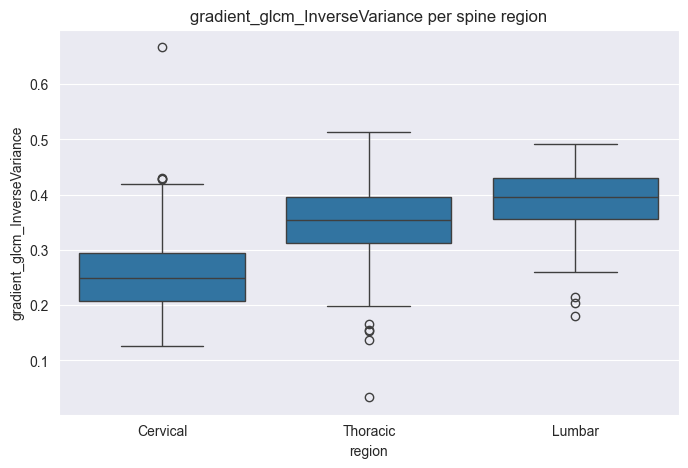

In [58]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# --- 1. Load all lesion CSVs ---
main_folder = r"E:\DATA_Myelomy"
lesion_data = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)
    lesion_csv = os.path.join(folder_path, "monoe_40kev_radiomics_lesions_features.csv")
    if os.path.isfile(lesion_csv):
        df_l = pd.read_csv(lesion_csv)
        lesion_data.append(df_l)

# combine all lesion data
df = pd.concat(lesion_data, ignore_index=True)

# remove S1
df = df[df['vertebra_name'] != 'S1']

# --- 2. Define vertebra regions (C/T/L) ---
cervical = [f'C{i}' for i in range(1,8)]
thoracic = [f'T{i}' for i in range(1,13)]
lumbar = [f'L{i}' for i in range(1,6)]

def map_region(vertebra):
    if vertebra in cervical:
        return 'Cervical'
    elif vertebra in thoracic:
        return 'Thoracic'
    else:
        return 'Lumbar'

df['region'] = df['vertebra_name'].apply(map_region)

# --- 3. Identify numeric features automatically ---
non_feature_cols = ['vertebra_name', 'region', 'patient']
feature_cols = [c for c in df.columns if c not in non_feature_cols and pd.api.types.is_numeric_dtype(df[c])]

# --- 6. Kruskal–Wallis test per feature ---
kw_results = []
for f in feature_cols:
    groups = [df.loc[df['region']==r, f].dropna().values for r in ['Cervical','Thoracic','Lumbar']]
    H, p = kruskal(*groups)
    n = df[f].notna().sum()
    kw_results.append({'feature': f, 'H_stat': H, 'p_value': p})

kw_df = pd.DataFrame(kw_results).sort_values('H_stat', ascending=False)
print(kw_df.head())

# --- 7. Boxplot example for top feature ---
top_feature = kw_df.iloc[0]['feature']
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y=top_feature, data=df)
plt.title(f'{top_feature} per spine region')
plt.ylabel(top_feature)
plt.show()

# % podiel objemu lezi -> typ myelomu

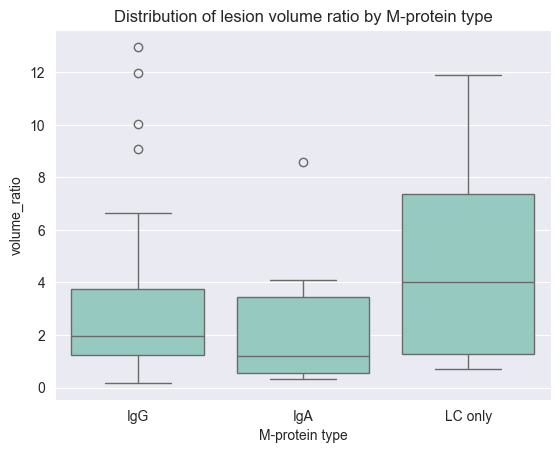

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'M-protein type']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
sns.boxplot(data=df_final, x="M-protein type", y="volume_ratio")
plt.title('Distribution of lesion volume ratio by M-protein type')
plt.show()

# % podiel objemu lezi -> serum M-protein

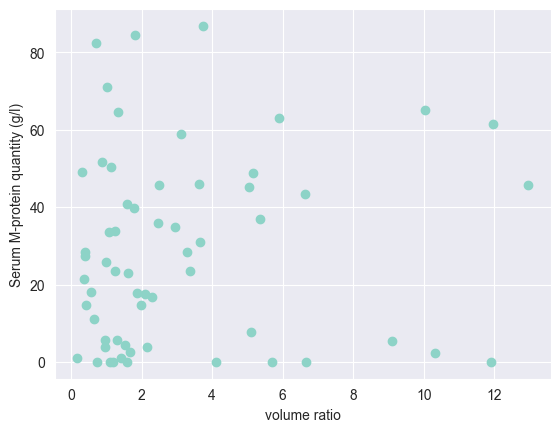

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df_lesions = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])
df_vertebrae = pd.read_csv(r"E:\CSV\merged\merged_CaSupp_25_radiomics_spine_vertebrae_features.csv").filter(items=["patient", "original_shape_VoxelVolume"])

df_lesions = df_lesions.rename(columns={'original_shape_VoxelVolume': 'lesions_volume'})
df_vertebrae = df_vertebrae.rename(columns={'original_shape_VoxelVolume': 'vertebrae_volume'})

data = pd.merge(df_lesions, df_vertebrae[['patient', 'vertebrae_volume']], left_on='patient', right_on='patient')

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[['Patient ID', 'Serum M-protein quantity (g/l)']], left_on='patient', right_on='Patient ID')

df_final['volume_ratio'] = df_final['lesions_volume'] / df_final['vertebrae_volume'] * 100
plt.scatter(df_final['volume_ratio'], df_final['Serum M-protein quantity (g/l)'])
plt.xlabel('volume ratio')
plt.ylabel('Serum M-protein quantity (g/l)')
plt.show()

# tumor max burden

Kruskal-Wallis test

M-protein type


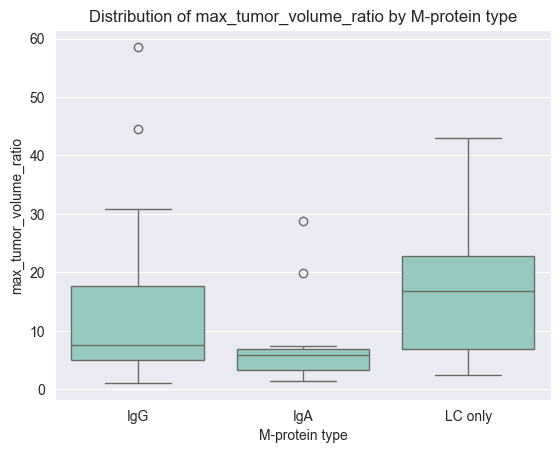

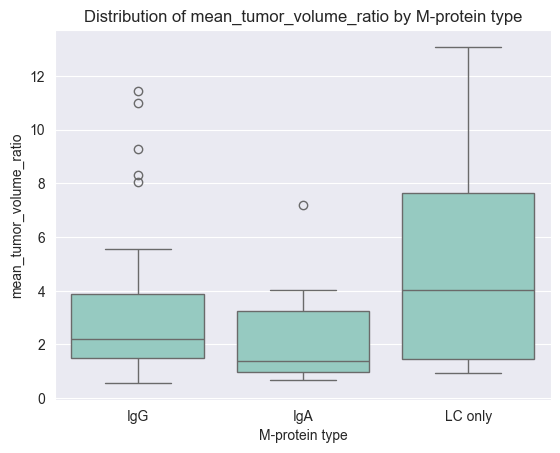

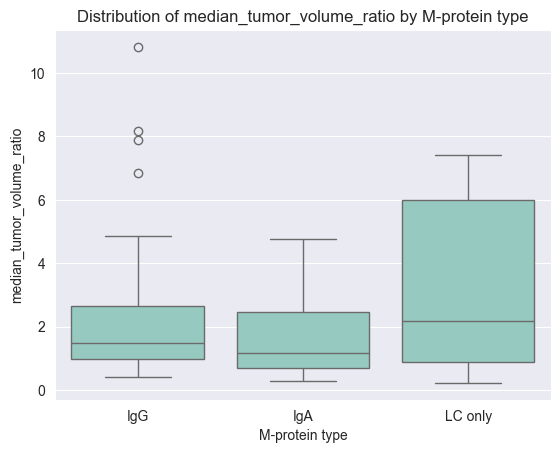

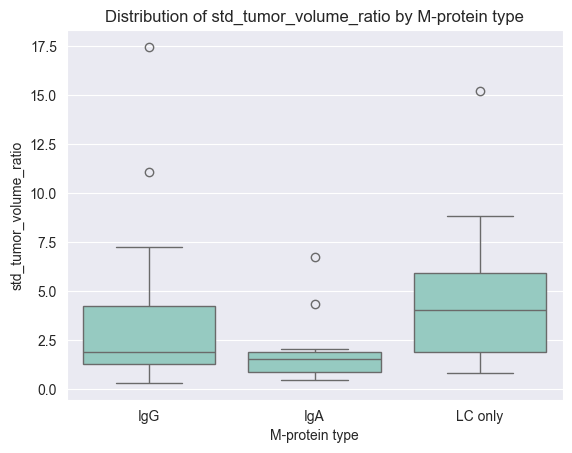

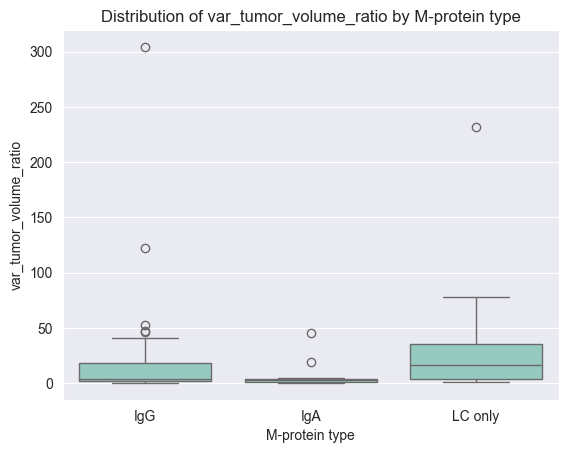

ISS classification


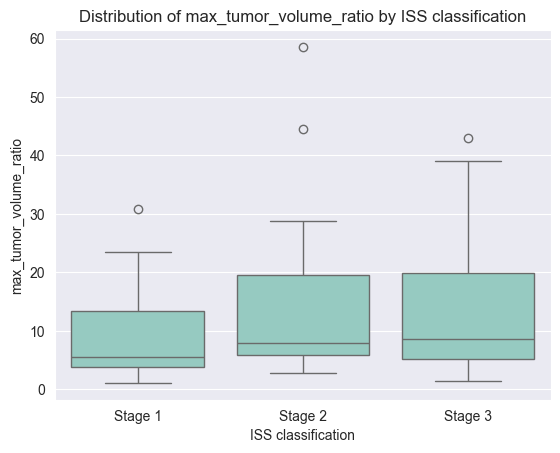

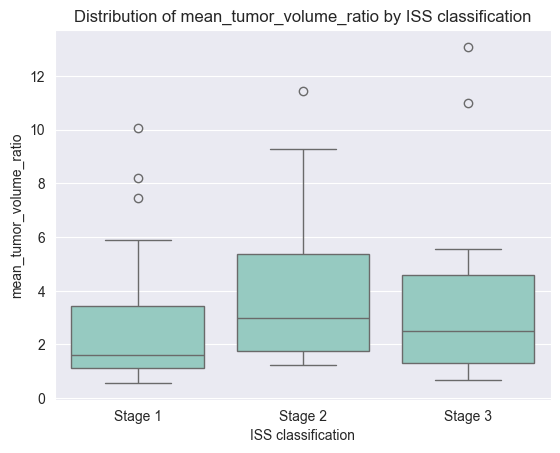

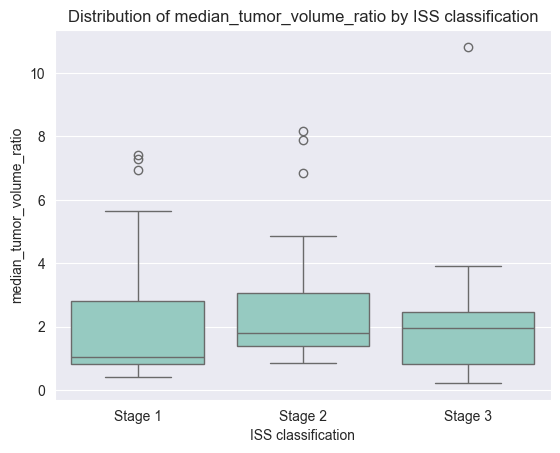

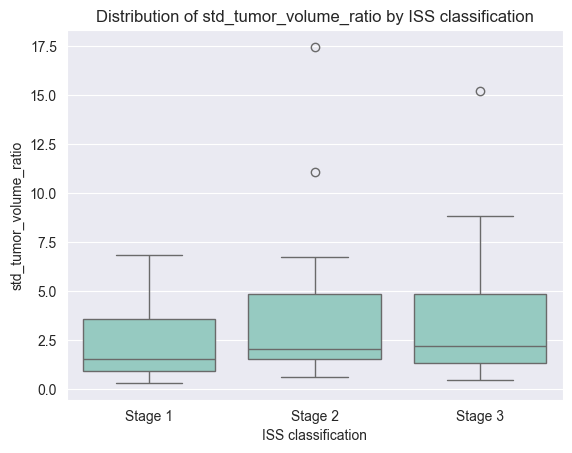

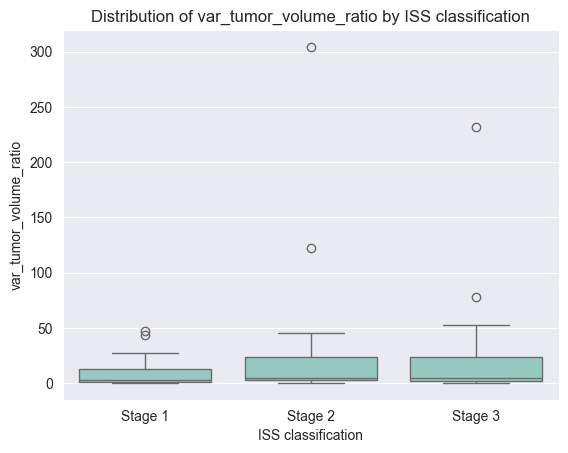

Serum M-protein quantity (g/l)


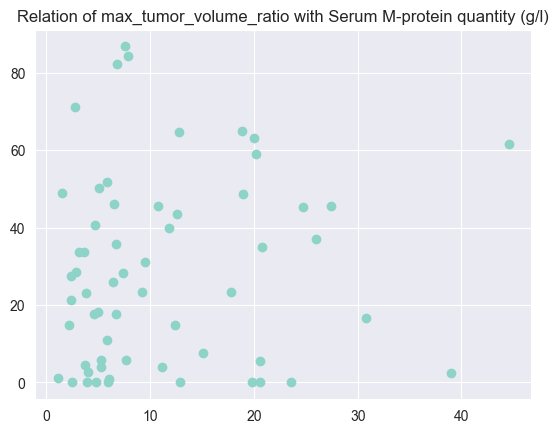

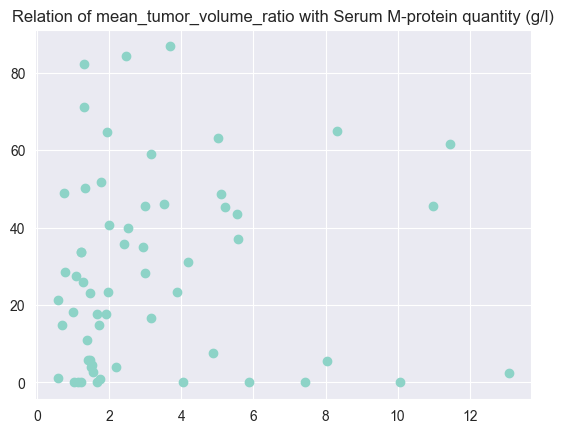

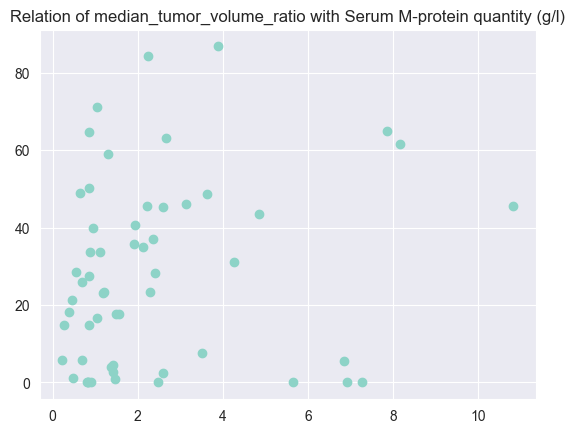

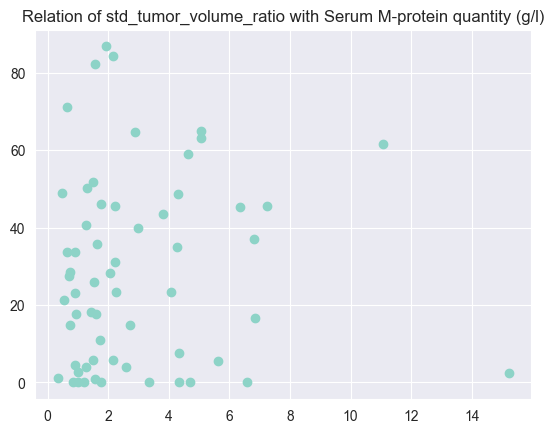

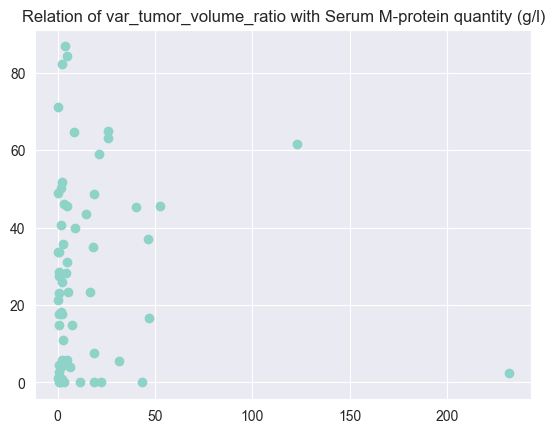

Plasmocyte count FC (%)


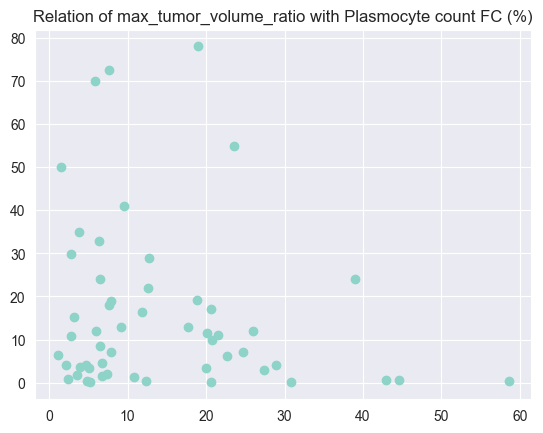

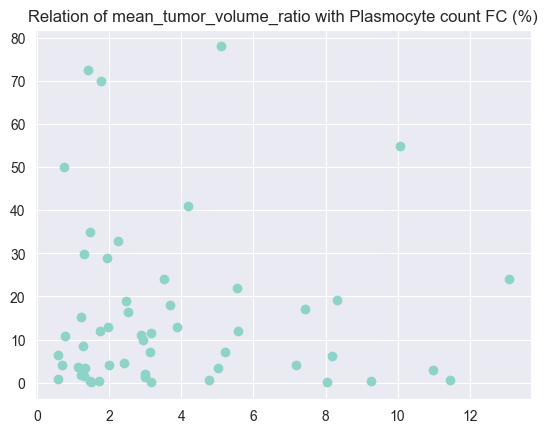

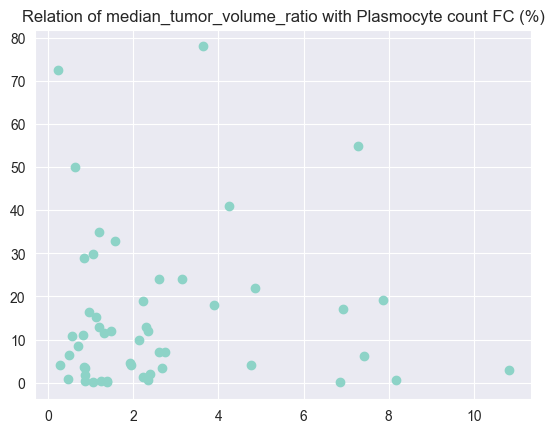

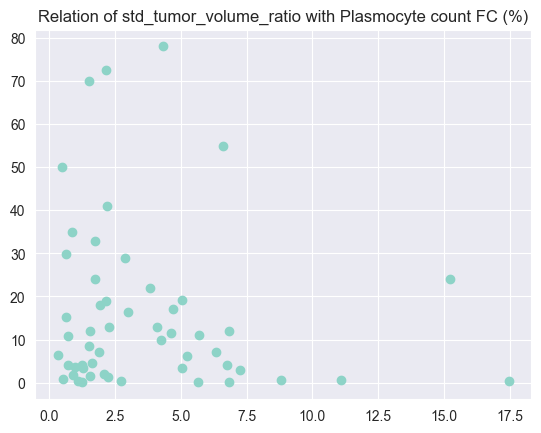

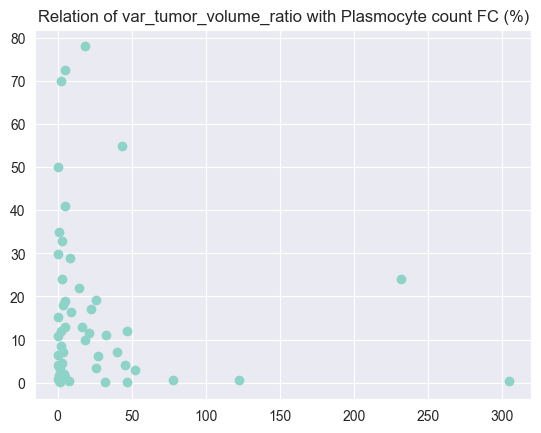

Beta2 microglobulin (mg/l)


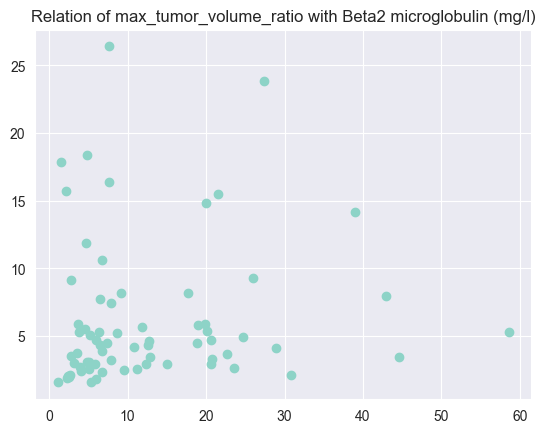

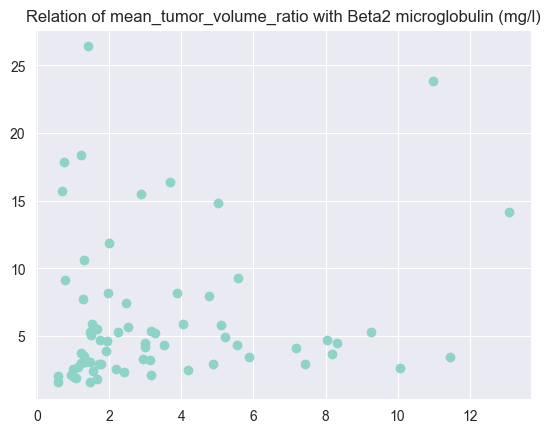

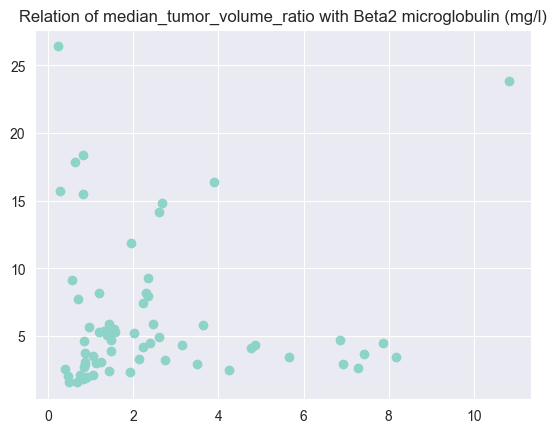

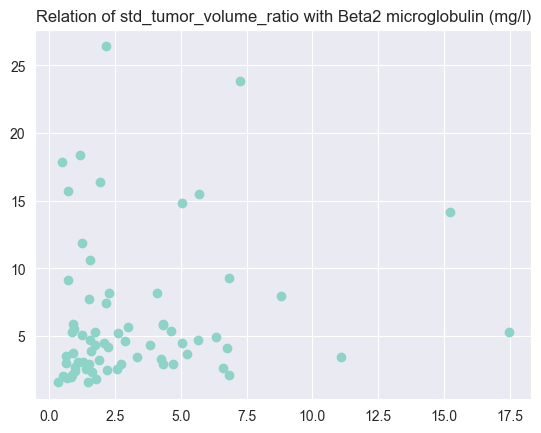

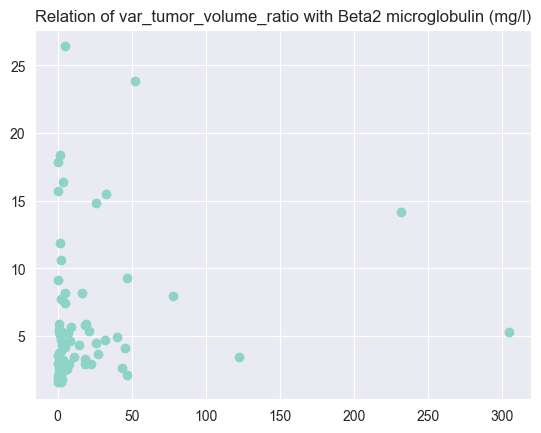

Creatinine level (µmol/l)


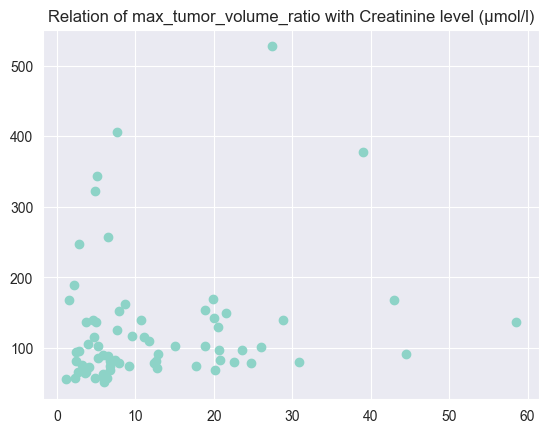

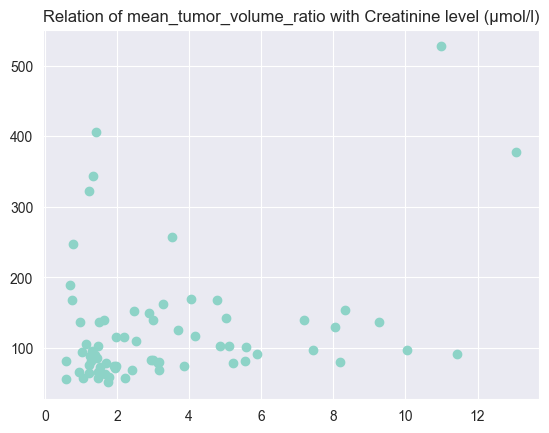

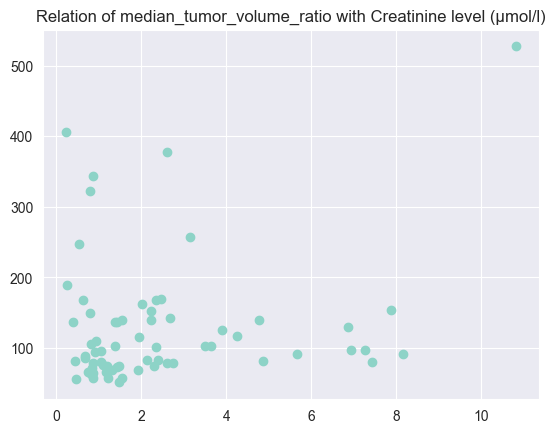

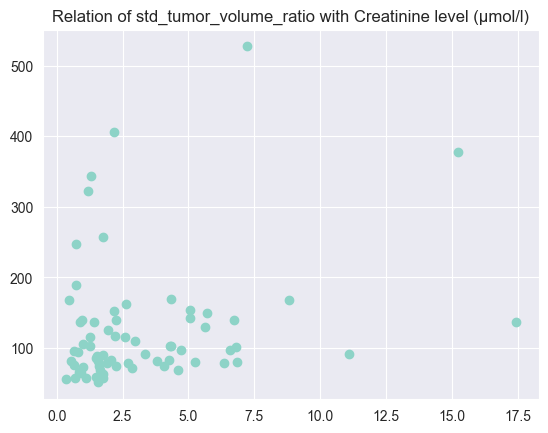

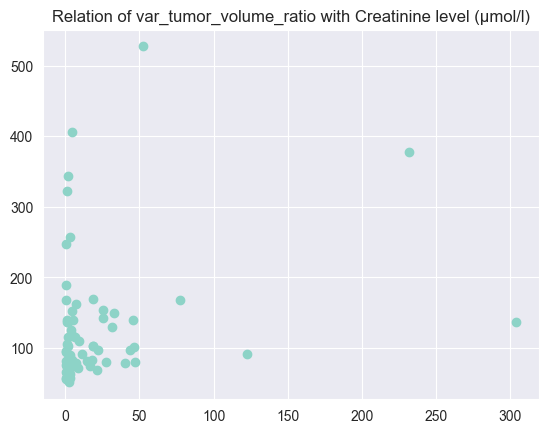

In [34]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


main_folder = r"E:\DATA_Myelomy"
features = ["vertebra_name", "original_shape_VoxelVolume"]

result = []

for folder_name in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder_name)

    lesions_path = os.path.join(folder_path, "BMD_radiomics_lesions_features.csv")
    vertebra_path = os.path.join(folder_path, "BMD_radiomics_vertebrae_features.csv")

    df_lesions = pd.read_csv(lesions_path).filter(items=features)
    df_vertebra = pd.read_csv(vertebra_path).filter(items=features)

    df_lesions["lesions_volume"] = df_lesions["original_shape_VoxelVolume"]
    df_vertebra["vertebra_volume"] = df_vertebra["original_shape_VoxelVolume"]

    merged_df = pd.merge(df_lesions, df_vertebra[['vertebra_name', 'vertebra_volume']],
                         left_on='vertebra_name', right_on='vertebra_name').drop("original_shape_VoxelVolume", axis=1)

    merged_df["tumor_volume_ratio"] = merged_df["lesions_volume"] / merged_df["vertebra_volume"] * 100

    temp = {
        "patient": folder_name,
        "max_tumor_volume_ratio": max(merged_df["tumor_volume_ratio"]),
        "mean_tumor_volume_ratio": np.mean(merged_df["tumor_volume_ratio"]),
        "median_tumor_volume_ratio": np.median(merged_df["tumor_volume_ratio"]),
        "std_tumor_volume_ratio": np.std(merged_df["tumor_volume_ratio"]),
        "var_tumor_volume_ratio": np.var(merged_df["tumor_volume_ratio"]),
    }

    result.append(temp)

data = pd.DataFrame(result)

pd.set_option('future.no_silent_downcasting', True)
categorical = ["M-protein type", "ISS classification"]
numeric = ["Serum M-protein quantity (g/l)", "Plasmocyte count FC (%)", "Beta2 microglobulin (mg/l)", "Creatinine level (µmol/l)"]
clinical_features = ["Patient ID"] + categorical + numeric
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
df_final = pd.merge(data, clinical_df[clinical_features], left_on='patient', right_on='Patient ID')

for category in categorical:
    print(category)
    for col in df_final.columns:
        if "tumor_volume_ratio" in col:
            sns.set_style("darkgrid")
            sns.boxplot(data=df_final, x=category, y=col)
            plt.title(f'Distribution of {col} by {category}')
            plt.show()

for num in numeric:
    print(num)
    for col in df_final.columns:
        if "tumor_volume_ratio" in col:
            plt.scatter(df_final[col], df_final[num], label=num)
            plt.title(f'Relation of {col} with {num}')
            plt.show()